In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

#from imblearn.over_sampling import SMOTENC

## Modeling (Name)

Predicting Credit Card Defaults

Mia Arnold - Katia Paredes - Harshali Gaikwad

Shirley Marcos School of Engineering, University of San Diego

ADS-505 Applied Data Science for Buisness

October 19th, 2026

## Table of Contents
1. [Data Preprocessing](#Data-Preprocessing)
2. [Modeling with Demographic Info](#Modeling-with-Demographic-Info)
3. [Modeling without Demographic Info](#Modeling-without-Demographic-Info)
4. [Model Performance](#Model-Performance)
5. [Model Selection](#Model-Selection)
6. [Discussion](#Discussion)

# Data Preprocessing

In [5]:
# load data

df_1 = pd.read_csv(
    "credit_default_engineered.csv"
)

df_2 = df_1.drop(
    columns=["SEX", "MARRIAGE", "AGE"]
)

print(f"Shape with demographics: {df_1.shape}")
print(f"Shape without demographics: {df_2.shape}")

Shape with demographics: (30000, 40)
Shape without demographics: (30000, 37)


In [6]:
# Stratified 60/20/20 train-validation-test split

target = df_1["DEFAULT"]

train_idx, temp_idx = train_test_split(
    df_1.index,
    test_size=0.40,
    random_state=42,
    stratify=target
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=target.loc[temp_idx]
)

print(f"Training observations: {len(train_idx)}")
print(f"Validation observations: {len(val_idx)}")
print(f"Test observations: {len(test_idx)}")

Training observations: 18000
Validation observations: 6000
Test observations: 6000


In [9]:
print("Overall default rate:", round(df_1["DEFAULT"].mean(), 4))
print("Training default rate:", round(y_train_1.mean(), 4))
print("Validation default rate:", round(y_val_1.mean(), 4))
print("Test default rate:", round(y_test_1.mean(), 4))

Overall default rate: 0.2212
Training default rate: 0.2212
Validation default rate: 0.2212
Test default rate: 0.2212


**Split Verification:** The dataset was divided into 60% training, 20%
validation, and 20% final test sets using stratified sampling. The default
rate remained approximately 22.12% in each subset, confirming that the class
distribution was preserved. The final test set will remain untouched until
the team's final model configuration has been selected.

In [28]:
X_train_1[
    ["SEX", "EDUCATION", "MARRIAGE"]
].dtypes

SEX          int64
EDUCATION    int64
MARRIAGE     int64
dtype: object

In [43]:
# Create model-specific preprocessing pipelines

def build_preprocessor(X, scale_numeric=True):
    """Create preprocessing for numeric and categorical predictors."""

    # Variables stored as numbers but conceptually categorical
    coded_categorical = [
        "SEX",
        "EDUCATION",
        "MARRIAGE"
    ]

    # Keep only those that exist in the current feature set
    coded_categorical = [
        col for col in coded_categorical
        if col in X.columns
    ]

    # Detect any categorical variables already stored as text/category
    detected_categorical = X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    categorical_cols = list(
        dict.fromkeys(
            coded_categorical + detected_categorical
        )
    )

    numeric_cols = [
        col for col in X.columns
        if col not in categorical_cols
    ]

    transformers = []

    if numeric_cols:
        numeric_transformer = (
            StandardScaler()
            if scale_numeric
            else "passthrough"
        )

        transformers.append(
            (
                "numeric",
                numeric_transformer,
                numeric_cols
            )
        )

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_cols
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

# Modeling with Demographic Info

In [4]:
# Adaboost


In [3]:
# Linear Discriminant Analysis (LDA)


In [44]:
# Baseline Random Forest with demographic information

rf_preprocessor_1 = build_preprocessor(
    X_train_1,
    scale_numeric=False
)

rf_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor_1),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_demo_pipeline.fit(
    X_train_1,
    y_train_1
)

rf_demo_pred = rf_demo_pipeline.predict(
    X_val_1
)

rf_demo_prob = rf_demo_pipeline.predict_proba(
    X_val_1
)[:, 1]

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [45]:
# Baseline Logistic Regression with demographic information

log_preprocessor_1 = build_preprocessor(
    X_train_1,
    scale_numeric=True
)

log_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", log_preprocessor_1),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

log_demo_pipeline.fit(
    X_train_1,
    y_train_1
)

log_demo_pred = log_demo_pipeline.predict(
    X_val_1
)

log_demo_prob = log_demo_pipeline.predict_proba(
    X_val_1
)[:, 1]

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [ ]:
# Neural Network


In [ ]:
# Decision Tree


# Modeling without Demographic Info

In [2]:
# Adaboost


In [1]:
# Linear Discriminant Analysis (LDA)


In [46]:
# Baseline Random Forest without demographic information

rf_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=False
)

rf_no_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor_2),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_no_demo_pipeline.fit(
    X_train_2,
    y_train_2
)

rf_no_demo_pred = rf_no_demo_pipeline.predict(
    X_val_2
)

rf_no_demo_prob = rf_no_demo_pipeline.predict_proba(
    X_val_2
)[:, 1]

print(
    "Baseline Random Forest without demographics "
    "trained successfully."
)

Baseline Random Forest without demographics trained successfully.


In [47]:
# Baseline Logistic Regression without demographic information

log_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=True
)

log_no_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", log_preprocessor_2),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

log_no_demo_pipeline.fit(
    X_train_2,
    y_train_2
)

log_no_demo_pred = log_no_demo_pipeline.predict(
    X_val_2
)

log_no_demo_prob = log_no_demo_pipeline.predict_proba(
    X_val_2
)[:, 1]

print(
    "Baseline Logistic Regression without demographics "
    "trained successfully."
)

Baseline Logistic Regression without demographics trained successfully.


In [ ]:
# Neural Network


In [ ]:
# Decision Tree


# Model Performance

In [48]:
# Reusable function for classification performance

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true, y_prob
        ),
        "PR_AUC": average_precision_score(
            y_true, y_prob
        )
    }

In [28]:
# Adaboost


In [29]:
# Linear Discriminant Analysis (LDA)


In [51]:
# Random Forest baseline validation performance

rf_baseline_result = evaluate_classifier(
    "Random Forest - Demographics",
    y_val_1,
    rf_demo_pred,
    rf_demo_prob
)

pd.DataFrame([rf_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Demographics,0.809,0.627,0.338,0.439,0.758,0.521


In [50]:
# Logistic Regression baseline validation performance

log_baseline_result = evaluate_classifier(
    "Logistic Regression - Demographics",
    y_val_1,
    log_demo_pred,
    log_demo_prob
)

pd.DataFrame([log_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression - Demographics,0.806,0.676,0.236,0.35,0.707,0.481


In [ ]:
# Neural Network


In [ ]:
# Decision Tree


In [52]:
# Compare Logistic Regression and Random Forest baseline performance

baseline_results_df = pd.DataFrame([
    log_baseline_result,
    rf_baseline_result
])

baseline_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression - Demographics,0.806,0.676,0.236,0.350,0.707,0.481
1,Random Forest - Demographics,0.809,0.627,0.338,0.439,0.758,0.521


In [53]:
# Confusion matrices for baseline models

print("Logistic Regression Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        log_demo_pred
    )
)

print("\nRandom Forest Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        rf_demo_pred
    )
)

Logistic Regression Confusion Matrix
[[4523  150]
 [1014  313]]

Random Forest Confusion Matrix
[[4407  266]
 [ 879  448]]


### Baseline Model Comparison

The baseline Random Forest model outperformed Logistic Regression on most
validation metrics. Random Forest achieved higher recall, F1-score, ROC-AUC,
and PR-AUC, indicating stronger ability to identify customers who ultimately
defaulted.

Logistic Regression produced higher precision, meaning that when it predicted
default, those predictions were more often correct. However, its substantially
lower recall indicates that it failed to identify many actual defaulters.

The confusion matrices reinforce this result. Logistic Regression identified
314 true defaults while missing 1,013, whereas Random Forest identified 453
true defaults while missing 874. Random Forest therefore provided a better
baseline balance between identifying high-risk customers and limiting false
positive predictions.

These are baseline results only. Hyperparameter tuning and class-imbalance
treatment may change the relative performance of the models.

In [54]:
# Compare all four baseline models on the validation set

all_baseline_results = [
    evaluate_classifier(
        "Logistic Regression - Demographics",
        y_val_1,
        log_demo_pred,
        log_demo_prob
    ),
    evaluate_classifier(
        "Random Forest - Demographics",
        y_val_1,
        rf_demo_pred,
        rf_demo_prob
    ),
    evaluate_classifier(
        "Logistic Regression - No Demographics",
        y_val_2,
        log_no_demo_pred,
        log_no_demo_prob
    ),
    evaluate_classifier(
        "Random Forest - No Demographics",
        y_val_2,
        rf_no_demo_pred,
        rf_no_demo_prob
    )
]

all_baseline_results_df = pd.DataFrame(
    all_baseline_results
)

all_baseline_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression - Demographics,0.806,0.676,0.236,0.350,0.707,0.481
1,Random Forest - Demographics,0.809,0.627,0.338,0.439,0.758,0.521
2,Logistic Regression - No Demographics,0.806,0.675,0.235,0.349,0.707,0.481
3,Random Forest - No Demographics,0.809,0.631,0.333,0.436,0.750,0.512


### Effect of Removing Demographic Predictors

Removing demographic predictors produced very little change in baseline model
performance. Logistic Regression showed effectively identical validation
metrics with and without demographic information. Random Forest experienced
only small reductions in recall, F1-score, ROC-AUC, and PR-AUC after
demographic variables were removed, while accuracy and precision increased
slightly.

These findings suggest that the demographic variables provide limited
incremental predictive value relative to the customers' credit, billing, and
repayment characteristics. Random Forest remained the stronger baseline model
for identifying defaults, achieving higher recall, F1-score, ROC-AUC, and
PR-AUC than Logistic Regression in both feature configurations.

Because these are baseline results, final conclusions will be made only after
hyperparameter tuning and validation-set comparison.

In [55]:
# Confusion matrices for models without demographic information

print("Logistic Regression - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        log_no_demo_pred
    )
)

print("\nRandom Forest - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        rf_no_demo_pred
    )
)

Logistic Regression - No Demographics
[[4523  150]
 [1015  312]]

Random Forest - No Demographics
[[4414  259]
 [ 885  442]]


In [56]:
# Compare performance change after removing demographic variables

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    "Logistic_With_Demo": [
        log_baseline_result["Accuracy"],
        log_baseline_result["Precision"],
        log_baseline_result["Recall"],
        log_baseline_result["F1"],
        log_baseline_result["ROC_AUC"],
        log_baseline_result["PR_AUC"]
    ],
    "Logistic_No_Demo": [
        all_baseline_results[2]["Accuracy"],
        all_baseline_results[2]["Precision"],
        all_baseline_results[2]["Recall"],
        all_baseline_results[2]["F1"],
        all_baseline_results[2]["ROC_AUC"],
        all_baseline_results[2]["PR_AUC"]
    ],
    "RF_With_Demo": [
        rf_baseline_result["Accuracy"],
        rf_baseline_result["Precision"],
        rf_baseline_result["Recall"],
        rf_baseline_result["F1"],
        rf_baseline_result["ROC_AUC"],
        rf_baseline_result["PR_AUC"]
    ],
    "RF_No_Demo": [
        all_baseline_results[3]["Accuracy"],
        all_baseline_results[3]["Precision"],
        all_baseline_results[3]["Recall"],
        all_baseline_results[3]["F1"],
        all_baseline_results[3]["ROC_AUC"],
        all_baseline_results[3]["PR_AUC"]
    ]
})

comparison.round(3)

,Metric,Logistic_With_Demo,Logistic_No_Demo,RF_With_Demo,RF_No_Demo
0,Accuracy,0.806,0.806,0.809,0.809
1,Precision,0.676,0.675,0.627,0.631
2,Recall,0.236,0.235,0.338,0.333
3,F1,0.350,0.349,0.439,0.436
4,ROC_AUC,0.707,0.707,0.758,0.750
5,PR_AUC,0.481,0.481,0.521,0.512


## Hyperparameter Tuning

In [58]:
# Stratified 5-fold cross-validation

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [60]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

In [59]:
log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

In [61]:
# Tune Logistic Regression with demographic information

log_grid_demo = GridSearchCV(
    estimator=log_demo_pipeline,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

log_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(log_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(log_grid_demo.best_score_, 3)
)

Best parameters:
{'model__C': 1, 'model__class_weight': 'balanced'}
Best cross-validation ROC-AUC: 0.727


In [62]:
# Evaluate tuned Logistic Regression on validation data

best_log_demo = log_grid_demo.best_estimator_

tuned_log_demo_pred = best_log_demo.predict(
    X_val_1
)

tuned_log_demo_prob = best_log_demo.predict_proba(
    X_val_1
)[:, 1]

tuned_log_demo_result = evaluate_classifier(
    "Tuned Logistic Regression - Demographics",
    y_val_1,
    tuned_log_demo_pred,
    tuned_log_demo_prob
)

pd.DataFrame(
    [tuned_log_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Regression - Demographics,0.7,0.387,0.617,0.476,0.708,0.478


In [63]:
# Tune Logistic Regression without demographic information

log_grid_no_demo = GridSearchCV(
    estimator=log_no_demo_pipeline,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

log_grid_no_demo.fit(
    X_train_2,
    y_train_2
)

print("Best parameters:")
print(log_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(log_grid_no_demo.best_score_, 3)
)

Best parameters:
{'model__C': 10, 'model__class_weight': 'balanced'}
Best cross-validation ROC-AUC: 0.727


In [64]:
# Evaluate tuned Logistic Regression without demographics

best_log_no_demo = log_grid_no_demo.best_estimator_

tuned_log_no_demo_pred = best_log_no_demo.predict(
    X_val_2
)

tuned_log_no_demo_prob = best_log_no_demo.predict_proba(
    X_val_2
)[:, 1]

tuned_log_no_demo_result = evaluate_classifier(
    "Tuned Logistic Regression - No Demographics",
    y_val_2,
    tuned_log_no_demo_pred,
    tuned_log_no_demo_prob
)

pd.DataFrame(
    [tuned_log_no_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Regression - No Demographics,0.7,0.387,0.616,0.476,0.708,0.478


In [65]:
# Random Forest hyperparameter grid

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 3],
    "model__class_weight": [None, "balanced"]
}

In [69]:
# Tune Random Forest with demographic information

rf_grid_demo = GridSearchCV(
    estimator=rf_demo_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

rf_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(rf_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(rf_grid_demo.best_score_, 3)
)

Best parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Best cross-validation ROC-AUC: 0.783


In [70]:
# Evaluate tuned Random Forest with demographics

best_rf_demo = rf_grid_demo.best_estimator_

tuned_rf_demo_pred = best_rf_demo.predict(
    X_val_1
)

tuned_rf_demo_prob = best_rf_demo.predict_proba(
    X_val_1
)[:, 1]

tuned_rf_demo_result = evaluate_classifier(
    "Tuned Random Forest - Demographics",
    y_val_1,
    tuned_rf_demo_pred,
    tuned_rf_demo_prob
)

pd.DataFrame(
    [tuned_rf_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Random Forest - Demographics,0.813,0.656,0.324,0.434,0.776,0.536


In [71]:
# Tune Random Forest without demographic information

rf_grid_no_demo = GridSearchCV(
    estimator=rf_no_demo_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

rf_grid_no_demo.fit(
    X_train_2,
    y_train_2
)

print("Best parameters:")
print(rf_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(rf_grid_no_demo.best_score_, 3)
)

Best parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Best cross-validation ROC-AUC: 0.782


In [72]:
# Evaluate tuned Random Forest without demographics

best_rf_no_demo = rf_grid_no_demo.best_estimator_

tuned_rf_no_demo_pred = best_rf_no_demo.predict(
    X_val_2
)

tuned_rf_no_demo_prob = best_rf_no_demo.predict_proba(
    X_val_2
)[:, 1]

tuned_rf_no_demo_result = evaluate_classifier(
    "Tuned Random Forest - No Demographics",
    y_val_2,
    tuned_rf_no_demo_pred,
    tuned_rf_no_demo_prob
)

pd.DataFrame(
    [tuned_rf_no_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Random Forest - No Demographics,0.811,0.644,0.322,0.429,0.777,0.535


In [73]:
# Compare tuned Logistic Regression and Random Forest models

tuned_model_comparison = pd.DataFrame([
    tuned_log_demo_result,
    tuned_log_no_demo_result,
    tuned_rf_demo_result,
    tuned_rf_no_demo_result
])

tuned_model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Regression - Demographics,0.700,0.387,0.617,0.476,0.708,0.478
1,Tuned Logistic Regression - No Demographics,0.700,0.387,0.616,0.476,0.708,0.478
2,Tuned Random Forest - Demographics,0.813,0.656,0.324,0.434,0.776,0.536
3,Tuned Random Forest - No Demographics,0.811,0.644,0.322,0.429,0.777,0.535


In [74]:
# Confusion matrices for tuned models

print("Tuned Logistic Regression - Demographics")
print(confusion_matrix(y_val_1, tuned_log_demo_pred))

print("\nTuned Logistic Regression - No Demographics")
print(confusion_matrix(y_val_2, tuned_log_no_demo_pred))

print("\nTuned Random Forest - Demographics")
print(confusion_matrix(y_val_1, tuned_rf_demo_pred))

print("\nTuned Random Forest - No Demographics")
print(confusion_matrix(y_val_2, tuned_rf_no_demo_pred))

Tuned Logistic Regression - Demographics
[[3378 1295]
 [ 508  819]]

Tuned Logistic Regression - No Demographics
[[3379 1294]
 [ 509  818]]

Tuned Random Forest - Demographics
[[4448  225]
 [ 897  430]]

Tuned Random Forest - No Demographics
[[4437  236]
 [ 900  427]]


### Interpretation of Tuned Model Performance

The tuned Logistic Regression models achieved substantially higher recall than
the tuned Random Forest models. This means Logistic Regression identified a
larger proportion of customers who actually defaulted. However, this improvement
came with a large increase in false-positive predictions.

Random Forest produced much higher precision, accuracy, ROC-AUC, and PR-AUC.
The confusion matrices show that Random Forest classified non-defaulting
customers more accurately, but it missed more actual defaulters.

The choice between the models therefore depends on the business objective. If
the priority is identifying as many potentially defaulting customers as
possible, Logistic Regression may be preferable. If the priority is stronger
overall discrimination and fewer unnecessary interventions, Random Forest may
be preferable.

### Hyperparameter Tuning Summary

Hyperparameter tuning affected Logistic Regression and Random Forest differently.
For Logistic Regression, GridSearchCV selected balanced class weights for both
versions of the model. This substantially increased recall, allowing the models
to identify a larger proportion of customers who actually defaulted, although
precision and overall accuracy decreased.

For Random Forest, GridSearchCV selected 200 estimators, a maximum depth of 10,
a minimum leaf size of 3, and no class weighting. The tuned Random Forest models
achieved stronger ROC-AUC and PR-AUC values than Logistic Regression, indicating
better overall discrimination between defaulters and non-defaulters.

Performance was very similar between the models with and without demographic
variables, suggesting that the demographic predictors contributed relatively
little additional predictive information.

In [76]:
# Feature importance for tuned Random Forest with demographics

rf_feature_names = (
    best_rf_demo
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_importances = (
    best_rf_demo
    .named_steps["model"]
    .feature_importances_
)

rf_feature_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values(
    "Importance",
    ascending=False
)

rf_feature_importance.head(15)

,Feature,Importance
2,numeric__PAY_0,0.217090
3,numeric__PAY_2,0.081346
4,numeric__PAY_3,0.058137
6,numeric__PAY_5,0.045655
5,numeric__PAY_4,0.040413
7,numeric__PAY_6,0.031080
14,numeric__PAY_AMT1,0.030929
26,numeric__UTIL_AVG,0.024883
27,numeric__UTIL_MAX,0.023772
29,numeric__UTIL_CHANGE,0.023129


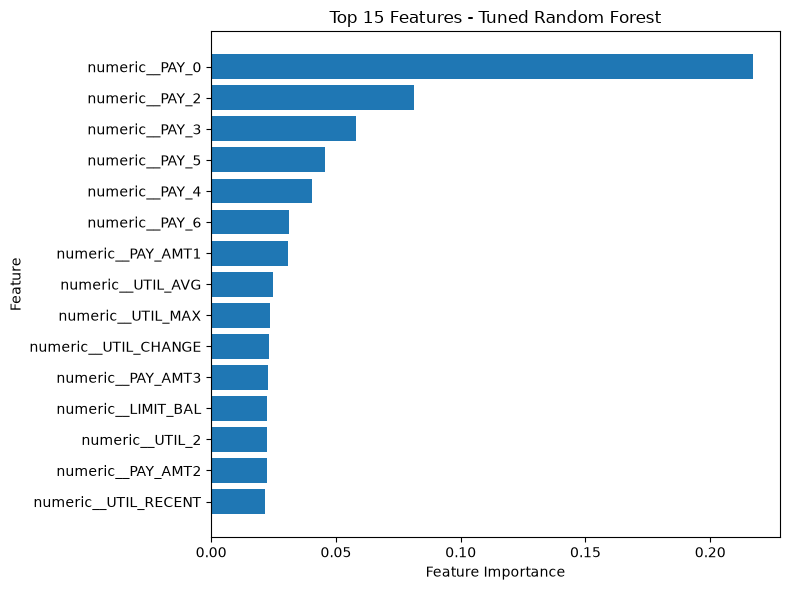

In [77]:
# Plot top 15 Random Forest feature importances

top_rf_features = rf_feature_importance.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_rf_features["Feature"][::-1],
    top_rf_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Tuned Random Forest")

plt.tight_layout()
plt.show()

In [78]:
# Logistic Regression coefficients with demographics

log_feature_names = (
    best_log_demo
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

log_coefficients = (
    best_log_demo
    .named_steps["model"]
    .coef_[0]
)

log_coef_df = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_coefficients
})

log_coef_df["Absolute_Coefficient"] = (
    log_coef_df["Coefficient"].abs()
)

log_coef_df = log_coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

log_coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
38,categorical__EDUCATION_label_Other,-0.614668,0.614668
33,categorical__EDUCATION_4,-0.614668,0.614668
2,numeric__PAY_0,0.594930,0.594930
51,categorical__LIMIT_BAND_> 500K,0.493966,0.493966
46,categorical__AGE_GROUP_70+,0.257597,0.257597
15,numeric__PAY_AMT2,-0.240276,0.240276
45,categorical__AGE_GROUP_60-69,0.213216,0.213216
0,numeric__LIMIT_BAL,-0.196744,0.196744
13,numeric__BILL_AMT6,-0.189594,0.189594
48,categorical__LIMIT_BAND_300K-500K,0.184228,0.184228


### Model Interpretation

The tuned Random Forest model identified repayment history as the most important
source of predictive information. `PAY_0`, representing the most recent repayment
status, had the largest feature importance by a substantial margin. Other recent
repayment-status variables, including `PAY_2` through `PAY_6`, were also among
the most influential predictors. Payment amounts, credit utilization measures,
and credit limit also contributed to the model.

The Logistic Regression coefficients similarly showed that recent repayment
status, particularly `PAY_0`, was strongly associated with predicted default.
Several credit-limit, payment, utilization, age, and education-related variables
also had relatively large coefficients. Positive coefficients indicate an
increase in the predicted log-odds of default, while negative coefficients
indicate a decrease, holding the other model variables constant.

Overall, both modeling approaches indicate that repayment behavior provides
substantial information for identifying customers at higher risk of default.

# Model Selection

# Discussion